In [57]:
#import các thư viện cần thiết
import numpy as np
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
#đọc dữ loeeju
train_df = pd.read_csv("/content/drive/MyDrive/AI/titanic_train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/AI/titanic_test.csv")

In [59]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [60]:
#Cột SibSp là cột số lượng người thân or vợ chồng với hành khách
#Cột Parch là cột số lượng ba mẹ or con với hành khách

test_df.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [61]:
#preview data
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [62]:
#chuyển cột passengerid thành cột chỉ mục
train_df.set_index(train_df.PassengerId,inplace=True)

In [63]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,,
1,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [64]:
train_df.drop('PassengerId', axis = 1, inplace = True)

In [65]:
train_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [66]:
test_df = pd.read_csv("/content/drive/MyDrive/AI/titanic_test.csv", index_col="PassengerId")

In [67]:
test_df.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [68]:
#Cột Age, Cabin, Embarked bị thiếu dữ liệu
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [69]:
#Cột Age, Cabin,Embarked   cũng bị thiếu dữ liệu
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    object 
 2   Sex       418 non-null    object 
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Ticket    418 non-null    object 
 7   Fare      417 non-null    float64
 8   Cabin     91 non-null     object 
 9   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 35.9+ KB


In [70]:
#chuyển đổi các cột thành kiểu category
features= ["Pclass","Sex","Embarked","SibSp","Parch"]
def convert_cat(df,features):
  for feature in features:
    df[feature]= df[feature].astype("category")
convert_cat(train_df,features)
convert_cat(test_df,features)



PHÂN BỐ CÁC CỘT DẠNG NUMERICAL TRÊN SAMPLE


In [71]:
train_df.describe()

,Survived,Age,Fare
count,891.000000,714.000000,891.000000
mean,0.383838,29.699118,32.204208
std,0.486592,14.526497,49.693429
min,0.000000,0.420000,0.000000
25%,0.000000,20.125000,7.910400
50%,0.000000,28.000000,14.454200
75%,1.000000,38.000000,31.000000
max,1.000000,80.000000,512.329200


In [72]:
train_df.describe(include="category")

,Pclass,Sex,SibSp,Parch,Embarked
count,891,891,891,891,889
unique,3,2,7,7,3
top,3,male,0,0,S
freq,491,577,608,678,644


**EDA CHO CATEGORICAL FEATURES**

In [73]:
train_df["Survived"].value_counts(normalize=True).to_frame()

,proportion
Survived,
0,0.616162
1,0.383838


In [74]:
train_df["Sex"].value_counts(normalize=True).to_frame()

,proportion
Sex,
male,0.647587
female,0.352413


<Axes: xlabel='Sex', ylabel='count'>

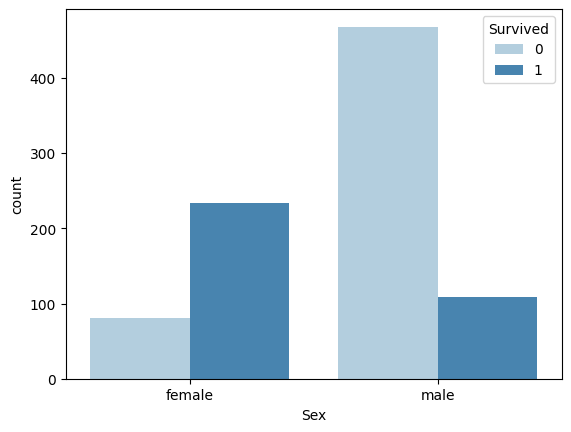

In [75]:
sns.countplot(data=train_df, x="Sex", palette="Blues", hue="Survived")

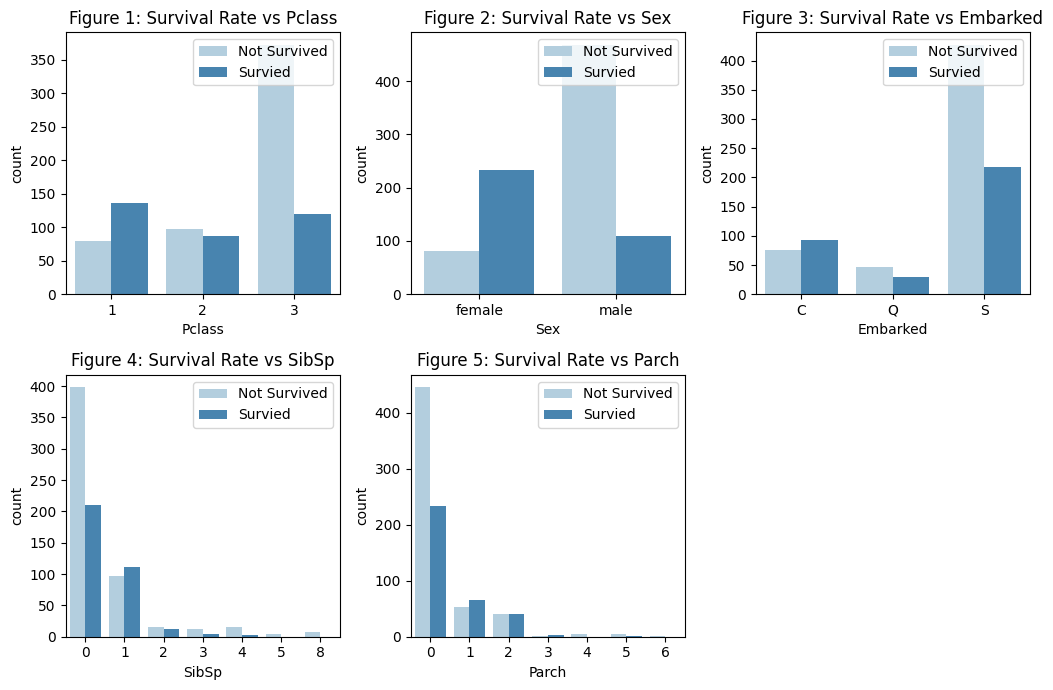

In [76]:
cols= ["Pclass","Sex","Embarked","SibSp","Parch"]
n_rows = 2
n_cols= 3
fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols*3.5, n_rows*3.5))
for r in range(0, n_rows):
  for c in range(0,n_cols):
    i = r*n_cols + c
    if i < len(cols):
      ax_i = ax[r,c]
      #Vẽ biểu đồ
      sns.countplot(data=train_df, x=cols[i],hue="Survived", palette="Blues", ax=ax_i)
      #Set tiêu đề cho mỗi subplot
      ax_i.set_title(f"Figure {i+1}: Survival Rate vs {cols[i]}")
      #Set chú thích cho mỗi subplot ( tiêu đề, vị trí, các nhãn)
      ax_i.legend(title ="", loc="upper right", labels=["Not Survived","Survied"])
ax.flat[-1].set_visible(False) # Ẩn subplot cuối
plt.tight_layout()


**EDA CHO NUMERICAL FEATURES**

<Axes: xlabel='Age', ylabel='Count'>

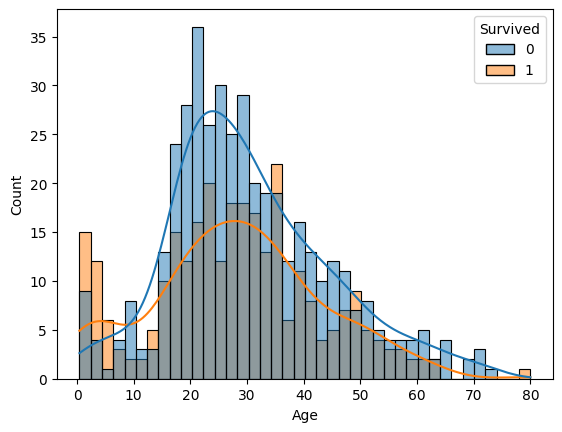

In [77]:
sns.histplot(data=train_df, x="Age", bins = 40, kde=True,hue="Survived")

In [78]:
train_df["Fare"].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


<Axes: xlabel='Fare', ylabel='Count'>

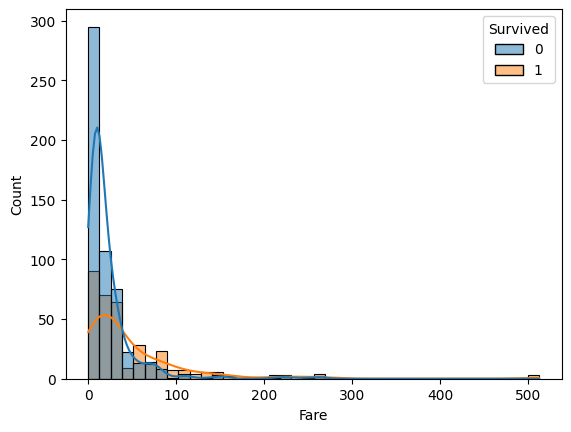

In [79]:
sns.histplot(data=train_df, x="Fare", bins = 40, kde=True,hue="Survived")

<Axes: xlabel='Fare', ylabel='count'>

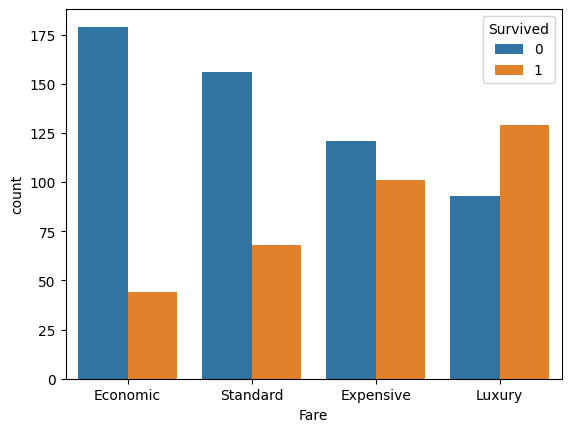

In [80]:
#Dán nhãn từng khoảng
fare_category =["Economic","Standard","Expensive", "Luxury"]
#Dán nhãn cho từng khoảng
quartile_data=pd.qcut(train_df["Fare"],4,labels=fare_category)
#Vẽ biểu đồ cho các khoảng
sns.countplot(x=quartile_data, hue=train_df["Survived"])

**Feature Engineering & Data Wrangling**

In [84]:
import re #regular expression
def extract_title(name):
  p = re.compile(r",([\w\s]+)\.")
  return p.search(name).groups(1)[0].strip()
train_df["Title"]= train_df["Name"].apply(lambda name: extract_title(name))
train_df["Title"].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [86]:
test_df["Title"]= test_df["Name"].apply(lambda name: extract_title(name))
test_df["Title"].value_counts()

,count
Title,
Mr,240
Miss,78
Mrs,72
Master,21
Col,2
Rev,2
Ms,1
Dr,1
Dona,1


<Axes: xlabel='Title', ylabel='count'>

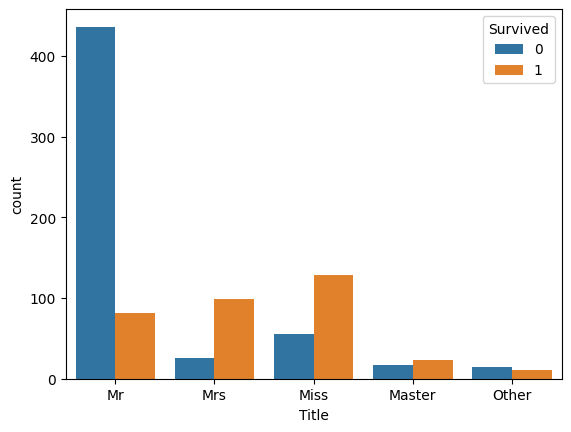

In [91]:
def group_title(title):
  if title in ["Mr", "Miss","Mrs","Master"]:
    return title
  elif title == "Ms":
    return "Miss"
  else:
    return "Other"
train_df["Title"] = train_df["Title"].apply(lambda title: group_title(title))
# train_df["Title"].value_counts()
test_df["Title"] = test_df["Title"].apply(lambda title: group_title(title))
sns.countplot(data=train_df, x="Title",hue="Survived")

In [92]:
train_df["Family_Size"] = train_df["SibSp"].astype("int") + train_df["Parch"].astype("int") + 1
test_df["Family_Size"] = test_df["SibSp"].astype("int") + test_df["Parch"].astype("int") + 1

<Axes: xlabel='Family_Size', ylabel='count'>

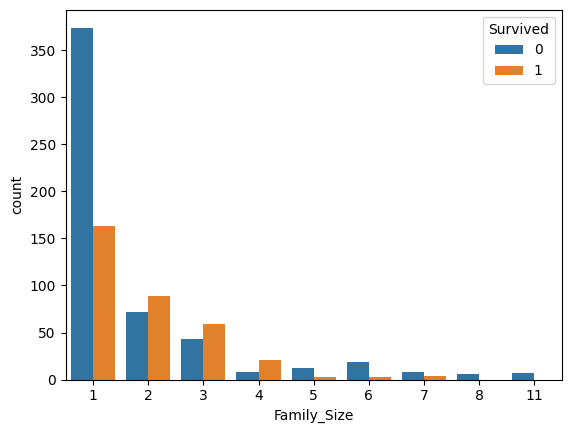

In [94]:
sns.countplot(data=train_df, x="Family_Size", hue="Survived")

<Axes: xlabel='Family_Cat', ylabel='count'>

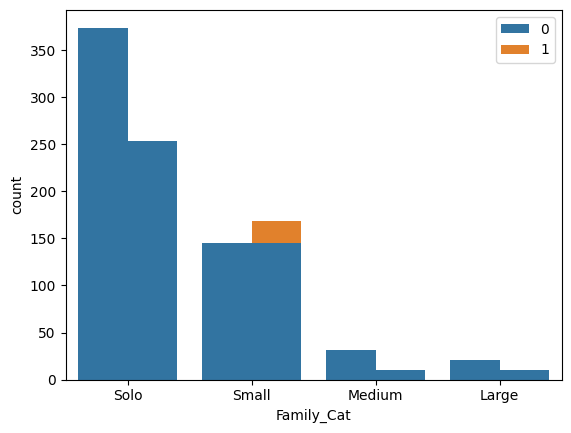

In [102]:
train_df["Family_Cat"]= pd.cut(train_df["Family_Size"], bins=[0,1,4,6,20], labels=["Solo","Small","Medium","Large"])
sns.countplot(data=train_df, x=train_df["Family_Cat"],hue="Survived")

test_df["Family_Cat"]= pd.cut(test_df["Family_Size"], bins=[0,1,4,6,20], labels=["Solo","Small","Medium","Large"])
sns.countplot(data=test_df, x=test_df["Family_Cat"])

In [97]:
num_features=["Age","Fare"]
cat_features =["Pclass","Sex","Embarked","Title","Family_Cat"]
feature_cols = num_features + cat_features

In [103]:
#Kiểm tra số lượng bị thiếu ở các cột của df
def display_missing(df,feature_cols):
  # n_rows = df.shape[0]
  for col in feature_cols:
    missing_count= df[col].isnull().sum()
    if missing_count > 0:
      print(f"Col {col} have {missing_count} missing values")
display_missing(train_df,feature_cols)
display_missing(test_df,feature_cols)

Col Age have 177 missing values
Col Embarked have 2 missing values
Col Age have 86 missing values
Col Fare have 1 missing values


In [108]:
#Tính toán các giá trị trung vị
age_by_sex_pclass = train_df.groupby(["Sex","Pclass"])["Age"].median()

/tmp/ipykernel_535/957593493.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_by_sex_pclass = train_df.groupby(["Sex","Pclass"])["Age"].median()


In [109]:
print(age_by_sex_pclass)

Sex     Pclass
female  1         35.0
        2         28.0
        3         21.5
male    1         40.0
        2         30.0
        3         25.0
Name: Age, dtype: float64


In [117]:
display_missing(train_df,feature_cols)
display_missing(test_df,feature_cols)
train_df["Age"] = train_df.groupby(['Sex',"Pclass"])["Age"].transform(lambda x: x.fillna(x.median()))
test_df["Age"] = test_df.groupby(['Sex',"Pclass"])["Age"].transform(lambda x: x.fillna(x.median()))

Col Embarked have 2 missing values


/tmp/ipykernel_535/3924520132.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df["Age"] = train_df.groupby(['Sex',"Pclass"])["Age"].transform(lambda x: x.fillna(x.median()))
/tmp/ipykernel_535/3924520132.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test_df["Age"] = test_df.groupby(['Sex',"Pclass"])["Age"].transform(lambda x: x.fillna(x.median()))


In [118]:
display_missing(test_df,feature_cols)


Col Fare have 1 missing values


In [119]:
X = train_df[feature_cols]
Y = train_df['Survived']

In [120]:
X_test = test_df[feature_cols]

In [124]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
num_transformer = Pipeline(steps = [
    {'imputer', SimpleImputer(strategy='median')},
    {'scaler', StandardScaler()}
])
cat_transformer = Pipeline(steps = [
    {'imputer', SimpleImputer(strategy='most_frequent')},
    {'encoder', OneHotEncoder(handle_unknown="ignore")}
])